# A Look Into MA Crossovers As Entry Signals For The S&P500 Index

*In this notebook I backtest whether simple strategies, centered on MA Crossovers, for timing market entry can provide superior market performance to a simple buy-and-hold Strategy. I will look to compare overall returns, various risk metrics and a standardised metric of risk adjusted returns. This analysis focuses on the S&P500 Index of US equities, using the SPY ETF for all data from the period 01-01-2013 to 31-12-2018. All pricing data is from the daily close price.*

*The first trading day of the sample is the first day with which we have values for all lengths of MA. For example, for 20, 50 and 100 day MAs, we require 100 days of data for computing initial MA values and thus we begin all strategies trading after the close of the 100th day, ie. the 101st day.* 
*The buy-and-hold strategy will consist of putting the entire portfolio value into the SPY ETF on the first trading day.*
*The MA Crossover strategy is as follows:*
- *If the quicker MA (fewer computed days) exceeds the slower MA at the end of a trading day, then the portfolio will be long its value in the SPY ETF for the next trading day.*
- *If the slower MA exceeds the faster MA at the end of a trading day, then the portfolio will be held in cash, and offer no returns the following trading day.*
- *No short selling is permitted.*
  
*For all strategies a transaction cost of 2bps is implemented for every change in position. This is consistent with the low transaction costs associated with highly liquid ETF products like SPY.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
spy_data = pd.read_csv("spy_data.csv", skiprows=[1,2], index_col=0, parse_dates=True)
spy_data.index.name = "Date"
spy_data.head()

,Close,High,Low,Open,Volume
Date,,,,,
2013-01-02,116.291718,116.363372,115.232781,115.535338,192059000
2013-01-03,116.028992,116.538554,115.718477,116.236009,144761800
2013-01-04,116.538551,116.729642,115.981220,116.220080,116817700
2013-01-07,116.220062,116.331529,115.790112,116.124523,110002500
2013-01-08,115.885651,116.172280,115.431816,116.013044,121265100


In [3]:
spy_close_price = spy_data["Close"]
ret = spy_close_price.pct_change().fillna(0)
ma_20 = spy_close_price.rolling(20).mean()
ma_50 = spy_close_price.rolling(50).mean()
ma_100 = spy_close_price.rolling(100).mean()

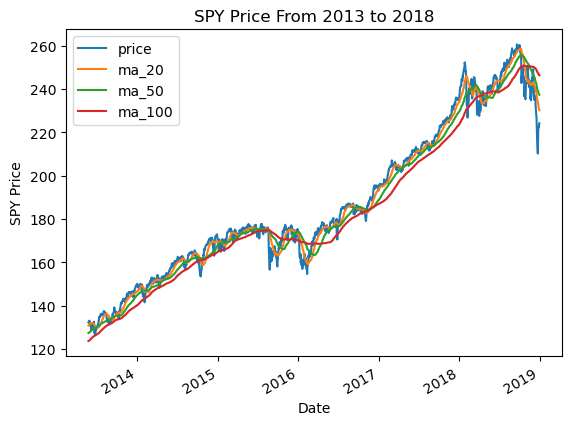

In [4]:
df = pd.DataFrame({"price": spy_close_price, "ret": ret, "ma_20": ma_20, "ma_50": ma_50, "ma_100": ma_100}).dropna()
df[["price", "ma_20", "ma_50", "ma_100"]].plot(title="SPY Price From 2013 to 2018", ylabel="SPY Price");

In [5]:
signal_20_50 = (df["ma_20"] > df["ma_50"]).astype(int)
signal_20_100 = (df["ma_20"] > df["ma_100"]).astype(int)
position_20_50 = signal_20_50.shift(1).fillna(0)
position_20_100 = signal_20_100.shift(1).fillna(0)
position_bah = pd.Series([0] + [1]*(len(position_20_50) - 1), index=position_20_50.index)

In [6]:
trade_20_50 = position_20_50.diff().abs().fillna(position_20_50.iloc[0]).astype(int)
trade_20_100 = position_20_100.diff().abs().fillna(position_20_100.iloc[0]).astype(int)
bah_trade = position_bah.diff().abs().fillna(position_bah.iloc[0]).astype(int)

In [7]:
cost_per_trade = 0.0002 #assuming trading a liquid etf has transaction costs of approx 2bps
cost_20_50 = trade_20_50 * cost_per_trade
cost_20_100 = trade_20_100 * cost_per_trade
bah_cost = bah_trade * cost_per_trade

In [8]:
strat_20_50_returns = (1 + (position_20_50 * df["ret"])) * (1 - cost_20_50) - 1
strat_20_100_returns = (1 + (position_20_100 * df["ret"])) * (1 - cost_20_100) - 1
bah_returns = (1 + (position_bah * df["ret"])) * (1 - bah_cost) - 1
trade_counts = pd.Series({"20/50 MA Crossover Strategy": trade_20_50.sum(),
                          "20/100 MA Crossover Strategy": trade_20_100.sum(),
                          "Buy-And-Hold Strategy": bah_trade.sum()}, 
                         name = "Number of trades", dtype=int)

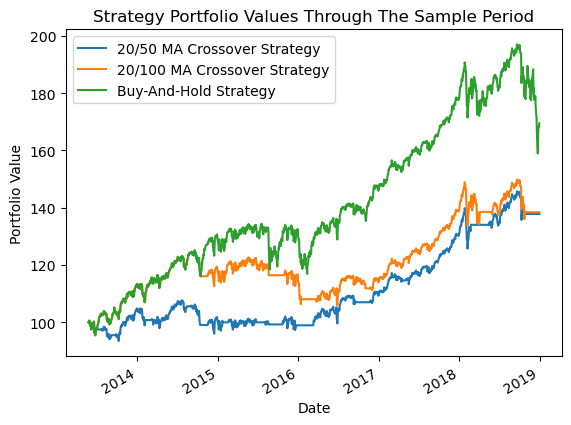

In [9]:
ma_20_50 = 100 * (1 + strat_20_50_returns).cumprod()
ma_20_100 = 100 * (1 + strat_20_100_returns).cumprod()
strategy_buy_hold = 100 * (1 + bah_returns).cumprod()
results = pd.concat([ma_20_50, ma_20_100, strategy_buy_hold], axis=1)
results.columns = ["20/50 MA Crossover Strategy", "20/100 MA Crossover Strategy", "Buy-And-Hold Strategy"]
results.plot(title="Strategy Portfolio Values Through The Sample Period", ylabel="Portfolio Value");

In [10]:
returns = pd.concat([strat_20_50_returns, strat_20_100_returns, bah_returns], axis=1)
returns.columns = ["20/50 MA Crossover Strategy", "20/100 MA Crossover Strategy", "Buy-And-Hold Strategy"] 
def total_return(rets):
    return (1 + rets).prod() - 1
def annualised_return(rets):
    return ((1 + rets).prod())**(252 / len(rets)) - 1
def annualised_vol(rets):
    return rets.std() * np.sqrt(252)
def annualised_sharpe(rets, rf=0):
    vol = annualised_vol(rets)
    if vol == 0:
        return np.nan
    return (annualised_return(rets) - rf) / vol
def drawdown(rets):
    cum_rets = (1 + rets).cumprod()
    return (cum_rets / cum_rets.cummax() - 1)
def max_drawdown(rets):
    return drawdown(rets).min()

functions = [total_return, annualised_return, annualised_vol, annualised_sharpe, max_drawdown]
summary = (returns.agg(functions))
summary.index = (["Total Period Return", "Annualised Return", "Annualised Volatility",
                                            "Annualised Sharpe Ratio", "Maximum Drawdown"])
summary.loc[trade_counts.name] = trade_counts
summary_display = summary.copy().astype(object)
summary_display.iloc[[0, 1, 2, 4]] = summary_display.iloc[[0, 1, 2, 4]].map(lambda x: f"{x:.2%}")
summary_display.iloc[3] = summary_display.iloc[3].map(lambda x: f"{x:.2f}")
summary_display.iloc[5] = summary_display.iloc[5].map(lambda x: f"{x:.0f}")
summary_display

,20/50 MA Crossover Strategy,20/100 MA Crossover Strategy,Buy-And-Hold Strategy
Total Period Return,37.84%,38.45%,69.51%
Annualised Return,5.90%,5.98%,9.88%
Annualised Volatility,9.38%,10.59%,12.97%
Annualised Sharpe Ratio,0.63,0.56,0.76
Maximum Drawdown,-10.84%,-15.34%,-19.35%
Number of trades,32,14,1


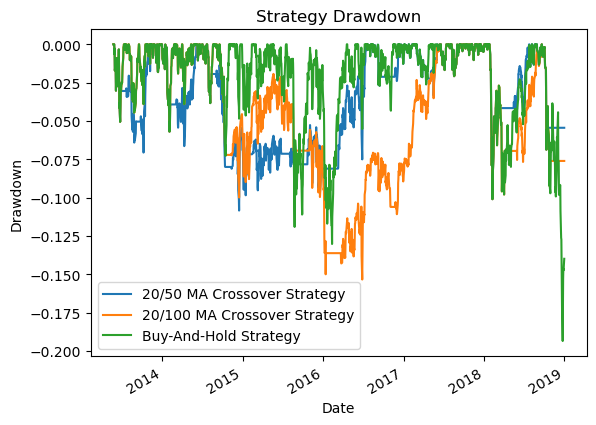

In [11]:
drawdown(returns).plot(title="Strategy Drawdown", ylabel="Drawdown");

*The simple Buy-And-Hold Strategy significantly out-performed both MA Crossover strategies in terms of total returns, materialising over 30% greater total period returns before even accounting for the trading costs. It is also the simplest strategy in terms of number of trades, requiring only an initial purchase whereas the 20-50 and 20-100 MA strategies required 32 and 14 trades respectively during the analysis period of around 5 years. However, if a premium is placed on avoiding large drawdowns, the 20-50 MA strategy may be preferable with a Maximum Drawdown of only 10.8% compared to the 15.3% of its slower MA counterpart and 19.3% for the simple Buy-And-Hold. Ultimately though, when we consider the Annualised Sharpe Ratios as a metric for standardised risk-adjusted returns, the Buy-And-Hold is once again superior with a ratio of 0.76, followed by 0.63 for the 20-50 MA and 0.56 for the 20-100 MA in last place. Over this sample period, buy-and-hold outperformed both MA strategies. This does not prove that market timing generally fails, but it does show how simple timing rules can underperform when they miss strong market days and incur trading costs. It also explores how a potential middle ground with the 20-100 MA strategy fails to provide the best of both worlds and instead offers both subpar returns and downside-mitigation resulting in a poor Sharpe Ratio.*

## Limitations

1. This analysis is limited to a single asset (SPY) and a single time period (2013–2018), which was largely characterised by a sustained bull market.
2. Results may not generalise to other assets or market regimes, particularly during periods of high volatility or prolonged downturns.
3. A basic parameter sweep and train/test split were performed, but the validation remains limited to one asset and one short out-of-sample period.
4. Transaction costs are simplified as a fixed 2 basis points per trade and do not account for slippage, bid-ask spreads, or execution delays, which could materially impact performance.
5. The use of unadjusted closing prices excludes dividends, which likely understates the performance of the buy-and-hold strategy.
6. The strategy assumes perfect execution at the next trading period following signal generation, which may not be achievable in practice.
7. Cash holdings are assumed to generate zero return, whereas in reality they may earn a positive risk-free rate.
8. The strategy is restricted to binary exposure (fully invested or fully in cash), and does not consider position sizing, leverage, or risk management techniques.
9. No statistical testing was conducted to assess whether observed performance differences are significant or could be attributed to randomness.

# Parameter Sweep: Testing MA Robustness

In [12]:
def ma_crossover_returns(price, short_window, long_window, trade_cost=0.0002):
    ma_short = price.rolling(short_window).mean()
    ma_long = price.rolling(long_window).mean()
    df = pd.DataFrame({"price": price, "ret": price.pct_change().fillna(0), "ma_short": ma_short, "ma_long": ma_long}).dropna()
    signal = (df["ma_short"] > df["ma_long"]).astype(int)
    position = signal.shift(1).fillna(0)
    trades = position.diff().abs().fillna(position.iloc[0]).astype(int)
    cost = trades * trade_cost
    return {"returns": (1 + (df["ret"] * position)) * (1 - cost) - 1, 
            "trades": trades}

def ma_pair(short_periods, long_periods):
    pairs = []
    for short in short_periods:
        for long in long_periods:
            if short >= long:
                continue
            pairs.append((short, long))
    return pairs

def ma_parameter_sweep(price, ma_pairs, start=None, end=None):
    sweep_results = []
    for short, long in ma_pairs:
        results = ma_crossover_returns(price, short, long)
        returns = results["returns"]
        trades = results["trades"]
        if start is not None or end is not None:
            returns = returns.loc[start:end]
            trades = trades.loc[start:end]
            
        sweep_results.append({
        "short window": short,
        "long window": long,
        "total return": total_return(returns),
        "annualised return": annualised_return(returns),
        "annualised volatility": annualised_vol(returns),
        "sharpe": annualised_sharpe(returns),
        "max drawdown": max_drawdown(returns),
        "number of trades": trades.sum()})
    sweep_df = pd.DataFrame(sweep_results)
    return sweep_df.sort_values(by="sharpe", ascending=False)

def sharpe_plot(df):
    sharpe_grid = df.pivot(
    index = "short window",
    columns = "long window",
    values = "sharpe"
    )
    plt.figure(figsize=(12, 6))
    plt.imshow(sharpe_grid, aspect="auto", origin="lower")
    plt.colorbar(label="Annualised Sharpe")
    plt.xticks(range(len(sharpe_grid.columns)), sharpe_grid.columns, rotation=90)
    plt.yticks(range(len(sharpe_grid.index)), sharpe_grid.index)
    plt.xlabel("Long MA Window")
    plt.ylabel("Short MA Window")
    plt.title("Sharpe Ratio Across MA Crossover Parameters")
    plt.show();

In [13]:
short_periods = range(5, 51, 5)
long_periods = range(20, 201, 10)

In [14]:
sweep_pairs =  ma_pair(short_periods, long_periods)
sweep_df = ma_parameter_sweep(spy_close_price, sweep_pairs)
sweep_df.head()

,short window,long window,total return,annualised return,annualised volatility,sharpe,max drawdown,number of trades
127,40,50,0.796569,0.106338,0.095467,1.113870,-0.101019,36
111,35,50,0.677578,0.093338,0.095901,0.973273,-0.105258,30
143,45,50,0.645933,0.089752,0.096584,0.929269,-0.101019,42
105,30,160,0.661897,0.099383,0.113267,0.877419,-0.119103,6
60,20,60,0.586386,0.083442,0.097307,0.857512,-0.112565,24


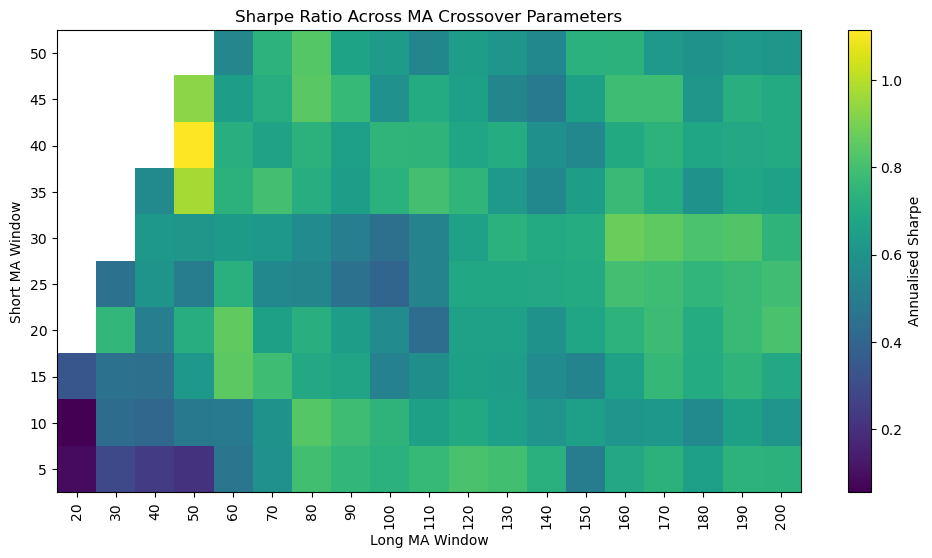

In [15]:
sharpe_plot(sweep_df)

This full-sample sweep is useful for visualising parameter sensitivity, but it should not be used for selecting strategies for out-of-sample testing because it includes the test period.

# Train/Test Split

In [16]:
train_df =  ma_parameter_sweep(spy_close_price, sweep_pairs, start="2013", end="2016")
train_df

,short window,long window,total return,annualised return,annualised volatility,sharpe,max drawdown,number of trades
127,40,50,0.418898,0.096298,0.096257,1.000430,-0.079545,29
143,45,50,0.388538,0.090085,0.096848,0.930171,-0.067684,33
146,45,80,0.375619,0.090358,0.107677,0.839155,-0.113561,7
57,20,30,0.317885,0.073636,0.089960,0.818544,-0.084779,41
105,30,160,0.331484,0.088693,0.114130,0.777123,-0.119103,5
...,...,...,...,...,...,...,...,...
77,25,50,0.073686,0.018858,0.100645,0.187373,-0.196683,27
2,5,40,0.048342,0.012353,0.089386,0.138202,-0.206708,47
3,5,50,0.032857,0.008531,0.092713,0.092018,-0.146212,43
19,10,20,-0.001648,-0.000420,0.084406,-0.004977,-0.221544,59


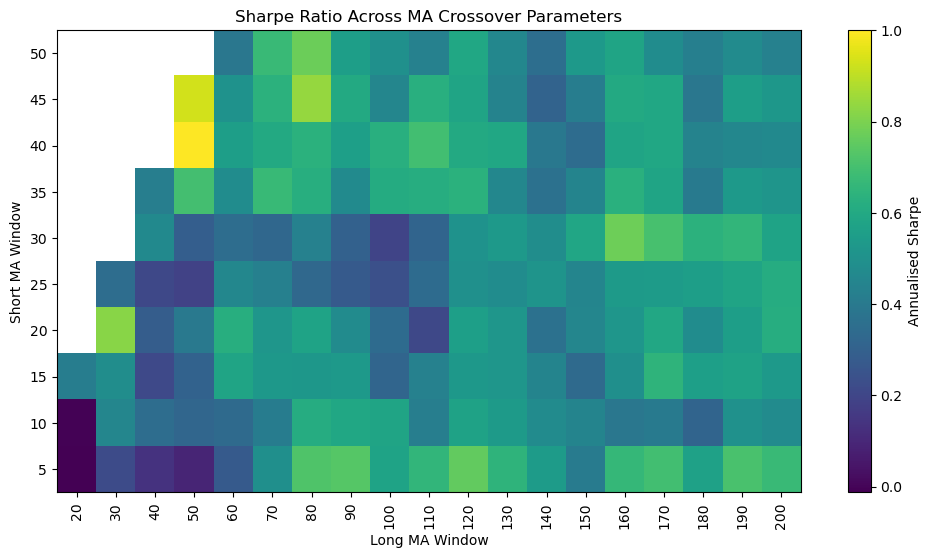

In [17]:
sharpe_plot(train_df)

The weakest performance is concentrated among shorter moving-average pairs, suggesting that high-turnover, reactive strategies are more vulnerable to noise and transaction costs. The strongest Sharpe ratios appear in a few localised regions rather than across one broad stable area, which weakens the case for a robust MA crossover effect in this sample. However, the 20–30 / 160–200 region and the 5 / 80–140 strip show more consistent performance, making them reasonable candidates for testing on the 2017–2018 holdout period.

In [18]:
robust_region_1 = [(a, b) for a in range(35, 46, 5) for b in range(50, 91, 10)]
robust_region_2 = [(a, b) for a in range(20, 31, 5) for b in range(160, 201, 10)]
robust_region_3 = [(a, b) for a in range(5, 6, 1) for b in range(80, 201, 10)]
test_region = robust_region_1 + robust_region_2 + robust_region_3

In [19]:
test_df = ma_parameter_sweep(spy_close_price, test_region, start="2017", end="2018")
test_df.head()

,short window,long window,total return,annualised return,annualised volatility,sharpe,max drawdown,number of trades
0,35,50,0.303672,0.142388,0.091036,1.564090,-0.101019,7
5,40,50,0.266172,0.125772,0.094024,1.337657,-0.101019,7
1,35,60,0.255133,0.120834,0.094277,1.281692,-0.101019,3
20,25,160,0.295733,0.138890,0.110696,1.254696,-0.101019,1
21,25,170,0.283076,0.133292,0.110936,1.201520,-0.101019,1


In [20]:
bah_summary = bah_returns["2017": "2018"].agg(functions)
bah_summary.index = ["Total Return", "Annualised Return", "Annualised Volatility", "Annualised Sharpe Ratio", "Maximum Drawdown"]
bah_summary

Total Return               0.161447
Annualised Return          0.078026
Annualised Volatility      0.129640
Annualised Sharpe Ratio    0.601863
Maximum Drawdown          -0.193489
dtype: float64

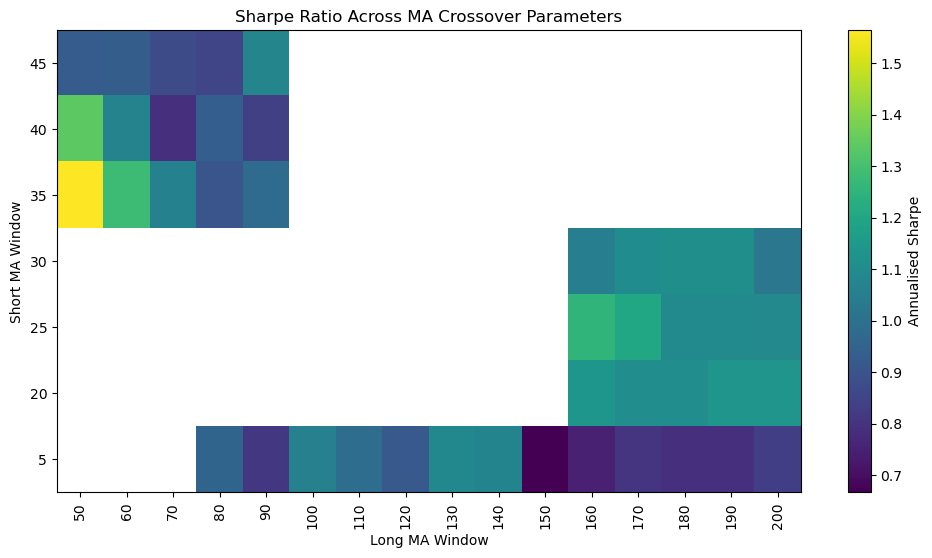

In [21]:
sharpe_plot(test_df)

The (35-45, 50-90) and (20-30, 160-200) regions remained relatively strong through the testing sample, suggesting they may be worth further testing, perhaps over different time frames and assets. The (5, X) strip however showed much poorer performance, indicating a lack of robustness in this sample. Importantly, these results should still be interpreted cautiously, since the test period is short and remains within the same broad post-2013 US equity regime.

# Conclusion

The initial 20/50 and 20/100 MA crossover strategies underperformed buy-and-hold over the full sample. A parameter sweep showed no broad, stable optimum, although several smaller regions performed well in-sample. When selected from the training period and tested on 2017–2018, two regions — (35–45, 50–90) and (20–30, 160–200) — again produced stronger Sharpe ratios than buy-and-hold, approximately 1.1 versus 0.6. However, given the short test period, single-asset setting, exclusion of dividends, simplified execution assumptions, and absence of statistical testing, these results should be treated as exploratory rather than evidence of a durable trading edge.